In [9]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from scipy.optimize import fsolve

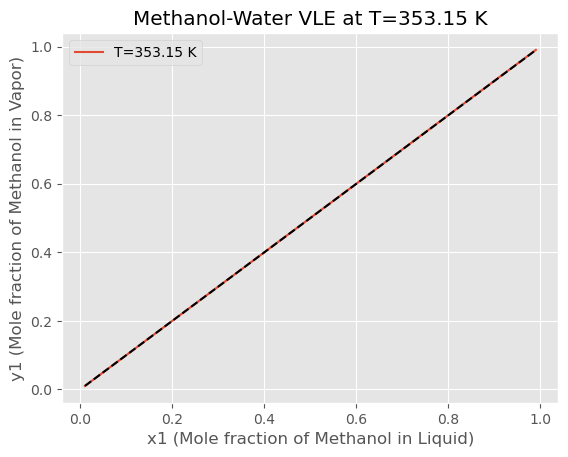

In [11]:

# methanol (0) and Water (1)
Pc = np.array([80.9, 220.6])  # bar
Tc = np.array([512.6, 647.1])  # K
omega = np.array([0.559, 0.344])  # acentric factor

# constants
R = 0.08314472  # L bar / mol K
a = 27/64 * (R**2 * Tc**2 / Pc)
b = R * Tc / (8 * Pc)

def vdw_volume(P, T, a, b, phase='vapor'):
    A = a * P / (R**2 * T**2)
    B = b * P / (R * T)

    
    A = a[component_idx] * P / (R**2 * T**2)
    B = b[component_idx] * P / (R * T)
    if phase == 'vapor':
        coeff = [1, -1, A - B - B**2, -A*B]
    else:
        coeff = [1, B - 1, A - 3*B**2 - 2*B, -(A*B + B**2 + B**3)]
    
    roots = np.roots(coeff)
    real_roots = roots[np.isreal(roots)].real
    if phase == 'vapor':
        selected_volume = np.max(real_roots)  # vapor phase has the largest volume
    else:
        selected_volume = np.min(real_roots)  # liquid phase has the smallest volume
    return selected_volume



T = 353.15
P = 1.01325  # Atmospheric pressure in bar
component_idx = 0  # Methanol

# composition range
x1 = np.linspace(0.01, 0.99, 100)
y1 = np.empty_like(x1)

for i, x in enumerate(x1):
    a_mix = x * a[0] + (1 - x) * a[1]
    b_mix = x * b[0] + (1 - x) * b[1]

    x2 = 1 - x
    # calculate fugacity coefficients
    V_L = vdw_volume(P, T, component_idx, 'liquid')
    V_V = vdw_volume(P, T, component_idx, 'vapor')
    phi1_L = np.exp(V_L/b_mix[0] - 1 - np.log(V_L/b[0] - 1))
    phi1_V = np.exp(V_V/b[0] - 1 - np.log(V_V/b[0] - 1))
    
    # Raoult's law for simplicity
    y1[i] = x * phi1_L / phi1_V

# plotting the xy diagram
fig, ax = plt.subplots()
ax.plot(x1, y1, label=f'T={T} K')
ax.plot(x1, x1, 'k--')
ax.set_xlabel('x1 (Mole fraction of Methanol in Liquid)')
ax.set_ylabel('y1 (Mole fraction of Methanol in Vapor)')
ax.set_title('Methanol-Water VLE at T=353.15 K')
ax.legend()
plt.show()
